In [1]:
import os
# os.environ["TF_USE_LEGACY_KERAS"] = "1"
# os.environ["TF_CUDNN_USE_FRONTEND"] = "0"  # optional, but keep if it helped your cuDNN situation

In [2]:
# --- Standard imports ---
import random
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from scipy import stats

from IPython.display import display, HTML

from sklearn.model_selection import train_test_split
from sklearn import metrics, preprocessing
from sklearn.metrics import classification_report

# --- TensorFlow + TFMOT (legacy tf.keras) ---
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from tensorflow import keras
from tensorflow.keras import layers, models

print("tensorflow:", tf.__version__)
print("tfmot:", tfmot.__version__)
print("keras module:", keras.__name__)

mkdir -p failed for path /shared/.cache/b00090279/matplotlib: [Errno 13] Permission denied: '/shared/.cache/b00090279'
Matplotlib created a temporary cache directory at /tmp/matplotlib-qksbmyij because there was an issue with the default path (/shared/.cache/b00090279/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
2026-03-04 08:18:09.683206: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-04 08:18:09.683252: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-04 08:18:09.683281: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to regist

tensorflow: 2.14.1
tfmot: 0.8.0
keras module: keras.api._v2.keras


In [3]:
# --- Check GPU availability ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Limit TensorFlow to only allocate memory as needed (instead of grabbing all GPU memory)
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPUs detected and enabled: {len(gpus)}")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected. Training will run on CPU.")

GPUs detected and enabled: 1


2026-03-04 08:18:28.057812: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-04 08:18:28.097257: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-04 08:18:28.100313: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [4]:
import tensorflow as tf
print("built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs:", tf.config.list_physical_devices("GPU"))
print(tf.sysconfig.get_build_info())

built with CUDA: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
OrderedDict([('cpu_compiler', '/usr/lib/llvm-16/bin/clang'), ('cuda_compute_capabilities', ['sm_35', 'sm_50', 'sm_60', 'sm_70', 'sm_75', 'compute_80']), ('cuda_version', '11.8'), ('cudnn_version', '8'), ('is_cuda_build', True), ('is_rocm_build', False), ('is_tensorrt_build', True)])


In [5]:
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
print("GPUs:", gpus)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = '42'

In [7]:
# reading raw data file
har_df = pd.read_csv('./WISDM_ar_v1.1/WISDM_ar_v1.1_raw.csv')

# removing null values
har_df = har_df.dropna()
har_df.shape

(1073623, 6)

In [8]:
# drop the rows where timestamp is 0
df = har_df[har_df['timestamp'] != 0]

# now arrange data in ascending order of the user and timestamp
df = df.sort_values(by = ['user', 'timestamp'], ignore_index=True)

In [9]:
har_df

,user,activity,timestamp,x-axis,y-axis,z-axis
0,1,Walking,4991922345000,0.69,10.80,-2.030000
1,1,Walking,4991972333000,6.85,7.44,-0.500000
2,1,Walking,4992022351000,0.93,5.63,-0.500000
3,1,Walking,4992072339000,-2.11,5.01,-0.690000
4,1,Walking,4992122358000,-4.59,4.29,-1.950000
...,...,...,...,...,...,...
1073618,36,Standing,15049012250000,-0.91,9.43,2.533385
1073619,36,Standing,15049062268000,-1.18,9.51,2.492524
1073620,36,Standing,15049112287000,-1.50,9.53,2.533385
1073621,36,Standing,15049162275000,-2.07,8.77,2.179256


In [10]:
# Define column name of the label vector
LABEL = 'ActivityEncoded'
# Transform the labels from String to Integer via LabelEncoder
le = preprocessing.LabelEncoder()
# Add a new column to the existing DataFrame with the encoded values
df[LABEL] = le.fit_transform(df['activity'].values.ravel())

In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 假设您的数据集如下
# df = pd.DataFrame({'x': [1, 2, 3], 'y': [4, 5, 6], 'z': [7, 8, 9]})

# 初始化StandardScaler
scaler = StandardScaler()

# 选择需要标准化的列
columns_to_scale = ['x-axis', 'y-axis', 'z-axis']

# 使用fit_transform标准化数据
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

# 查看标准化后的数据
print(df)


         user  activity       timestamp    x-axis    y-axis    z-axis  \
0           1   Walking   4991922345000  0.002594  0.514975 -0.507894   
1           1   Walking   4991972333000  0.893168  0.015937 -0.188432   
2           1   Walking   4992022351000  0.037292 -0.252891 -0.188432   
3           1   Walking   4992072339000 -0.402212 -0.344975 -0.228104   
4           1   Walking   4992122358000 -0.760755 -0.451912 -0.491190   
...       ...       ...             ...       ...       ...       ...   
1073618    36  Standing  15049012250000 -0.228724  0.311498  0.444935   
1073619    36  Standing  15049062268000 -0.267759  0.323380  0.436404   
1073620    36  Standing  15049112287000 -0.314022  0.326350  0.444935   
1073621    36  Standing  15049162275000 -0.396429  0.213473  0.370994   
1073622    36  Standing  15049212262000 -0.406549  0.379819  0.595663   

         ActivityEncoded  
0                      5  
1                      5  
2                      5  
3              

In [12]:
# # The number of steps within one time segment
# TIME_PERIODS = 100
# # The steps to take from one segment to the next; if this value is equal to
# # TIME_PERIODS, then there is no overlap between the segments
# STEP_DISTANCE = 50
# The number of steps within one time segment
TIME_PERIODS = 100
# The steps to take from one segment to the next; if this value is equal to
# TIME_PERIODS, then there is no overlap between the segments
STEP_DISTANCE = 50

In [13]:
from scipy.stats import moment

# x, y, z acceleration as features
N_FEATURES = 3

def create_segments_and_labels(df, time_steps, step, label_name):
    # Number of steps to advance in each iteration (for me, it should always
    # be equal to the time_steps in order to have no overlap between segments)
    # step = time_steps
    segments = []
    labels = []
    users =[]
    for i in range(0, len(df) - time_steps, step):
        xs = df['x-axis'].values[i: i + time_steps]
        ys = df['y-axis'].values[i: i + time_steps]
        zs = df['z-axis'].values[i: i + time_steps]
        # Retrieve the most often used label in this segment
        label = stats.mode(df[label_name].iloc[i:i+time_steps], keepdims=True).mode[0]
        segments.append([xs, ys, zs])
        labels.append(label)
        user  = stats.mode(df['user'].iloc[i:i+time_steps], keepdims=True).mode[0]
        users.append(user-1)

    # Bring the segments into a better shape
    reshaped_segments = np.asarray(segments, dtype= np.float32).reshape(-1, time_steps, N_FEATURES)
    labels = np.asarray(labels)
    users = np.asarray(users)

    return reshaped_segments, labels, users

x, y, y_users = create_segments_and_labels(df,
                                          TIME_PERIODS,
                                          STEP_DISTANCE,
                                          LABEL)

In [14]:
LABELS = ['Downstairs',
          'Jogging',
          'Sitting',
          'Standing',
          'Upstairs',
          'Walking']
print(LABELS)
print(le.transform(LABELS))

['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']
[0 1 2 3 4 5]


In [15]:
from tensorflow.keras.utils import to_categorical

Y_one_hot       = to_categorical(y)
Y_one_hot_users = to_categorical(y_users)

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train_one_hot, y_test_one_hot = train_test_split(x, Y_one_hot, test_size=0.33, random_state=42)

In [17]:
# import tensorflow as tf
# from tensorflow.keras import models, layers
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, Conv1D, MaxPooling1D
# from tensorflow.keras.utils import to_categorical

from tensorflow.keras import layers

In [18]:
model = models.Sequential()
model.add(layers.Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(100, 3)))
model.add(layers.Dropout(0.3))
model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(layers.Dropout(0.3))
# model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu'))
# model.add(layers.Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(layers.LSTM(units=100, return_sequences=True))
# model.add(layers.LSTM(units=100))
model.add(layers.Flatten())
model.add(layers.Dropout(0.3))
#model.add(layers.Dense(units=100, activation='relu'))
model.add(layers.Dense(units=6, activation='softmax'))


2026-03-04 08:18:43.847834: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-04 08:18:43.851101: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-03-04 08:18:43.854097: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:894] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [19]:
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 98, 32)            320       
                                                                 
 dropout (Dropout)           (None, 98, 32)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 96, 64)            6208      
                                                                 
 dropout_1 (Dropout)         (None, 96, 64)            0         
                                                                 
 lstm (LSTM)                 (None, 96, 100)           66000     
                                                                 
 flatten (Flatten)           (None, 9600)              0         
                                                                 
 dropout_2 (Dropout)         (None, 9600)              0

In [21]:
print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.14.1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
tf.debugging.set_log_device_placement(True)

In [27]:
#history = model.fit(x_train, y_train_one_hot, validation_data=(x_test, y_test_one_hot), epochs=30, batch_size=64)
history = model.fit(x_train, y_train_one_hot, epochs=50, batch_size=64, validation_data=(x_test, y_test_one_hot), callbacks=[
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
])

Epoch 1/50


2026-03-03 19:50:27.214792: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-03-03 19:50:27.360093: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-03 19:50:28.437756: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f0cbdaf1540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-03 19:50:28.437799: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A10G, Compute Capability 8.6
2026-03-03 19:50:28.444155: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-03 19:50:28.543990: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


225/225 [==============================] - 6s 11ms/step - loss: 0.6528 - accuracy: 0.7615 - val_loss: 0.4596 - val_accuracy: 0.8412 - lr: 0.0010
Epoch 2/50
225/225 [==============================] - 2s 8ms/step - loss: 0.4514 - accuracy: 0.8382 - val_loss: 0.3366 - val_accuracy: 0.8847 - lr: 0.0010
Epoch 3/50
225/225 [==============================] - 2s 8ms/step - loss: 0.3519 - accuracy: 0.8691 - val_loss: 0.3046 - val_accuracy: 0.8872 - lr: 0.0010
Epoch 4/50
225/225 [==============================] - 2s 8ms/step - loss: 0.2967 - accuracy: 0.8897 - val_loss: 0.2507 - val_accuracy: 0.9073 - lr: 0.0010
Epoch 5/50
225/225 [==============================] - 2s 8ms/step - loss: 0.2559 - accuracy: 0.9085 - val_loss: 0.2447 - val_accuracy: 0.9083 - lr: 0.0010
Epoch 6/50
225/225 [==============================] - 2s 8ms/step - loss: 0.2226 - accuracy: 0.9195 - val_loss: 0.2082 - val_accuracy: 0.9229 - lr: 0.0010
Epoch 7/50
225/225 [==============================] - 2s 8ms/step - loss: 0.1979

222/222 [==============================] - 1s 4ms/step - loss: 0.0693 - accuracy: 0.9824
Test Loss: 0.06928282976150513
Test Accuracy: 0.9823595881462097


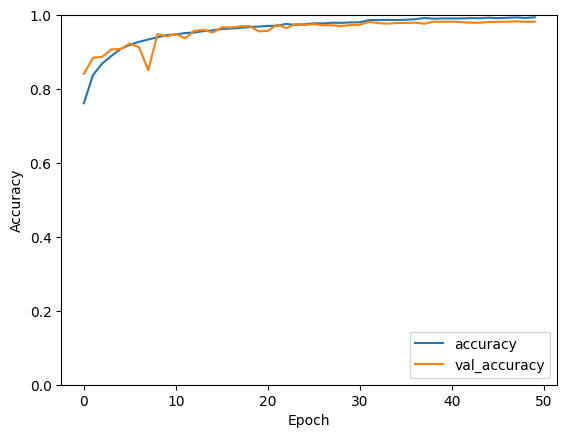

In [28]:
# 评估模型
loss, accuracy = model.evaluate(x_test, y_test_one_hot)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

# 绘制训练过程中的损失和准确率曲线
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [29]:
model.save("model_fp32.h5")

/shared/b00090279/tinymlproj/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [30]:
fp32_tflite_path = "model_fp32.tflite"
converter = tf.lite.TFLiteConverter.from_keras_model(model)
fp32_tflite = converter.convert()
open(fp32_tflite_path, "wb").write(fp32_tflite)

INFO:tensorflow:Assets written to: /tmp/tmpioq8drt1/assets


INFO:tensorflow:Assets written to: /tmp/tmpioq8drt1/assets
2026-03-03 19:56:58.282876: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 19:56:58.282917: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-03 19:56:58.283324: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpioq8drt1
2026-03-03 19:56:58.293238: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 19:56:58.293267: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpioq8drt1
2026-03-03 19:56:58.313544: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-03-03 19:56:58.318235: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-03-03 19:56:58.400596: I tensorflow/cc/saved_model/loader.cc:217] Running initializatio

ConverterError: /shared/b00090279/tinymlproj/lib/python3.10/runpy.py:196:1: error: 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
    return _run_code(code, main_globals, None,
^
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall"]): called from
/shared/b00090279/tinymlproj/lib/python3.10/runpy.py:196:1: error: failed to legalize operation 'tf.TensorListReserve' that was explicitly marked illegal
    return _run_code(code, main_globals, None,
^
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall"]): called from
<unknown>:0: error: Lowering tensor list ops is failed. Please consider using Select TF ops and disabling `_experimental_lower_tensor_list_ops` flag in the TFLite converter object. For example, converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]\n converter._experimental_lower_tensor_list_ops = False


### You’re hitting a known TFLite conversion failure with LSTM: during conversion, Keras’ LSTM path uses TensorList/TensorArray ops (e.g., tf.TensorListReserve) that TFLite can’t “lower” unless you either (a) allow Select TF ops or (b) force a TFLite-friendly LSTM (static shapes / unrolled / built-in LSTM).

### Fix B (usually best for “pure” TFLite): make the LSTM unrolled

In [31]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 98, 32)            320       
                                                                 
 dropout (Dropout)           (None, 98, 32)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 96, 64)            6208      
                                                                 
 dropout_1 (Dropout)         (None, 96, 64)            0         
                                                                 
 lstm (LSTM)                 (None, 96, 100)           66000     
                                                                 
 flatten (Flatten)           (None, 9600)              0         
                                                                 
 dropout_2 (Dropout)         (None, 9600)              0

In [42]:
model_unrolled_equiv = tf.keras.Sequential([
    tf.keras.layers.Conv1D(32, 3, activation="relu", input_shape=(100, 3)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Conv1D(64, 3, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.LSTM(100, return_sequences=True, unroll=True),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(6, activation="softmax"),
])

model_unrolled_equiv.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 98, 32)            320       
                                                                 
 dropout_15 (Dropout)        (None, 98, 32)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 96, 64)            6208      
                                                                 
 dropout_16 (Dropout)        (None, 96, 64)            0         
                                                                 
 lstm_5 (LSTM)               (None, 96, 100)           66000     
                                                                 
 flatten_5 (Flatten)         (None, 9600)              0         
                                                                 
 dropout_17 (Dropout)        (None, 9600)             

In [33]:
model_unrolled_equiv.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [34]:
#history = model.fit(x_train, y_train_one_hot, validation_data=(x_test, y_test_one_hot), epochs=30, batch_size=64)
history_unrolled = model_unrolled_equiv.fit(x_train, y_train_one_hot, epochs=50, batch_size=64, validation_data=(x_test, y_test_one_hot), callbacks=[
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
])

Epoch 1/50
225/225 [==============================] - 20s 45ms/step - loss: 0.6505 - accuracy: 0.7649 - val_loss: 0.4611 - val_accuracy: 0.8424 - lr: 0.0010
Epoch 2/50
225/225 [==============================] - 9s 39ms/step - loss: 0.4488 - accuracy: 0.8373 - val_loss: 0.3498 - val_accuracy: 0.8724 - lr: 0.0010
Epoch 3/50
225/225 [==============================] - 9s 39ms/step - loss: 0.3569 - accuracy: 0.8697 - val_loss: 0.3526 - val_accuracy: 0.8730 - lr: 0.0010
Epoch 4/50
225/225 [==============================] - 9s 39ms/step - loss: 0.3054 - accuracy: 0.8894 - val_loss: 0.2464 - val_accuracy: 0.9136 - lr: 0.0010
Epoch 5/50
225/225 [==============================] - 9s 39ms/step - loss: 0.2601 - accuracy: 0.9068 - val_loss: 0.2847 - val_accuracy: 0.8896 - lr: 0.0010
Epoch 6/50
225/225 [==============================] - 9s 39ms/step - loss: 0.2239 - accuracy: 0.9194 - val_loss: 0.1706 - val_accuracy: 0.9390 - lr: 0.0010
Epoch 7/50
225/225 [==============================] - 9s 39ms/s

222/222 [==============================] - 3s 12ms/step - loss: 0.0699 - accuracy: 0.9790
Test Loss: 0.06988652795553207
Test Accuracy: 0.9789726138114929


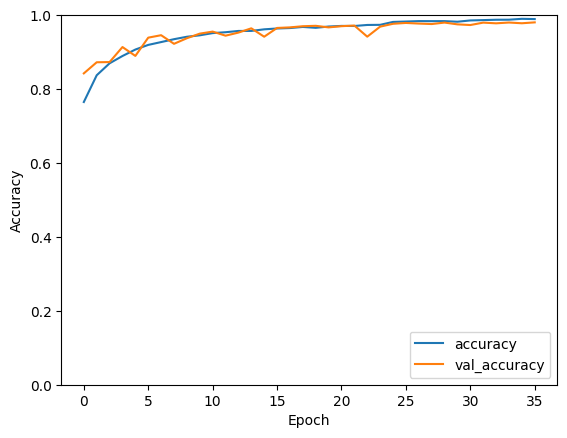

In [35]:
loss, accuracy = model_unrolled_equiv.evaluate(x_test, y_test_one_hot)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

import matplotlib.pyplot as plt

plt.plot(history_unrolled.history['accuracy'], label='accuracy')
plt.plot(history_unrolled.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [36]:
model_unrolled_equiv.save("model_unrolled_equiv_fp32.h5")

/shared/b00090279/tinymlproj/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [37]:
fp32_tflite_path = "model_unrolled_equiv_fp32.tflite"
converter = tf.lite.TFLiteConverter.from_keras_model(model_unrolled_equiv)
fp32_tflite = converter.convert()
open(fp32_tflite_path, "wb").write(fp32_tflite)

INFO:tensorflow:Assets written to: /tmp/tmp1w7vobqf/assets


INFO:tensorflow:Assets written to: /tmp/tmp1w7vobqf/assets
2026-03-03 20:04:52.969361: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-03 20:04:52.969405: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-03 20:04:52.969669: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp1w7vobqf
2026-03-03 20:04:52.987314: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-03 20:04:52.987342: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp1w7vobqf
2026-03-03 20:04:53.026851: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-03-03 20:04:53.155369: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp1w7vobqf
2026-03-03 20:04:53.251313: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

786496

In [38]:
# Load the TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path="model_unrolled_equiv_fp32.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Display Input Details
print("Input Details with Quantization Parameters:")
for input_detail in input_details:
    print(f"  Name: {input_detail['name']}")
    print(f"  Shape: {input_detail['shape']}")
    print(f"  Data Type: {input_detail['dtype']}")
    print(f"  Quantization Parameters: {input_detail['quantization']}")
    print(f"  Quantization Scale: {input_detail['quantization_parameters']['scales']}")
    print(f"  Quantization Zero Points: {input_detail['quantization_parameters']['zero_points']}\n")

# Display Output Details
print("\nOutput Details with Quantization Parameters:")
for output_detail in output_details:
    print(f"  Name: {output_detail['name']}")
    print(f"  Shape: {output_detail['shape']}")
    print(f"  Data Type: {output_detail['dtype']}")
    print(f"  Quantization Parameters: {output_detail['quantization']}")
    print(f"  Quantization Scale: {output_detail['quantization_parameters']['scales']}")
    print(f"  Quantization Zero Points: {output_detail['quantization_parameters']['zero_points']}\n")

Input Details with Quantization Parameters:
  Name: serving_default_conv1d_2_input:0
  Shape: [  1 100   3]
  Data Type: <class 'numpy.float32'>
  Quantization Parameters: (0.0, 0)
  Quantization Scale: []
  Quantization Zero Points: []


Output Details with Quantization Parameters:
  Name: StatefulPartitionedCall:0
  Shape: [1 6]
  Data Type: <class 'numpy.float32'>
  Quantization Parameters: (0.0, 0)
  Quantization Scale: []
  Quantization Zero Points: []



INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [39]:
ops = interpreter._get_ops_details()
op_names = sorted(set(op["op_name"] for op in ops))
print(op_names)
print("Has Flex?", any("Flex" in name for name in op_names))

['ADD', 'CONV_2D', 'EXPAND_DIMS', 'FILL', 'FULLY_CONNECTED', 'LOGISTIC', 'MUL', 'PACK', 'RESHAPE', 'SHAPE', 'SOFTMAX', 'SPLIT', 'STRIDED_SLICE', 'TANH', 'TRANSPOSE', 'UNPACK']
Has Flex? False


In [40]:
from tensorflow.keras.models import load_model

## Now we try annotating for QAT

In [41]:
pretrained_model = tf.keras.models.load_model("model_unrolled_equiv_fp32.h5")
qat_model_f = tfmot.quantization.keras.quantize_model(pretrained_model)
print("Converted model to QAT.")

RuntimeError: Layer conv1d_2:<class 'keras.src.layers.convolutional.conv1d.Conv1D'> is not supported. You can quantize this layer by passing a `tfmot.quantization.keras.QuantizeConfig` instance to the `quantize_annotate_layer` API.

## CONV1D is not supported, WE NEED CONV2D, LSTM is still unrolled for TFLITE+TFLM support

In [25]:
model_conv2d = tf.keras.Sequential([
    # Input: (time=100, features=3) -> add channel dim
    tf.keras.layers.Input(batch_shape=(1, 100, 3)),
    tf.keras.layers.Reshape((100, 1, 3)),          # (time, width=1, channels=features)

    tf.keras.layers.Conv2D(32, (3, 1), activation="relu", padding="valid"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Conv2D(64, (3, 1), activation="relu", padding="valid"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Reshape((96, 64)),             # now it's (96, 1, 64) -> (96, 64)

    tf.keras.layers.LSTM(100, return_sequences=True, unroll=True),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(6, activation="softmax"),
])

model_conv2d.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_2 (Reshape)         (None, 100, 1, 3)         0         
                                                                 
 conv2d_2 (Conv2D)           (None, 98, 1, 32)         320       
                                                                 
 dropout_6 (Dropout)         (None, 98, 1, 32)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 96, 1, 64)         6208      
                                                                 
 dropout_7 (Dropout)         (None, 96, 1, 64)         0         
                                                                 
 reshape_3 (Reshape)         (None, 96, 64)            0         
                                                                 
 lstm_2 (LSTM)               (None, 96, 100)          

In [24]:
model_unrolled_equiv.summary()

NameError: name 'model_unrolled_equiv' is not defined

In [26]:
model_conv2d.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [27]:
#history = model.fit(x_train, y_train_one_hot, validation_data=(x_test, y_test_one_hot), epochs=30, batch_size=64)
history_conv2d = model_conv2d.fit(x_train, y_train_one_hot, epochs=50, batch_size=64, validation_data=(x_test, y_test_one_hot), callbacks=[
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
])

Epoch 1/50


2026-03-04 08:19:23.166911: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2/dropout_6/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-03-04 08:19:23.340462: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-03-04 08:19:23.447547: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-03-04 08:19:24.516175: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x562def04d250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-04 08:19:24.516223: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A10G, Compute Capability 8.6
2026-03-04 08:19:24.522544: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env

225/225 [==============================] - 5s 10ms/step - loss: 0.6446 - accuracy: 0.7679 - val_loss: 0.5663 - val_accuracy: 0.7893 - lr: 0.0010
Epoch 2/50
225/225 [==============================] - 2s 8ms/step - loss: 0.4446 - accuracy: 0.8390 - val_loss: 0.3296 - val_accuracy: 0.8823 - lr: 0.0010
Epoch 3/50
225/225 [==============================] - 2s 8ms/step - loss: 0.3498 - accuracy: 0.8724 - val_loss: 0.2952 - val_accuracy: 0.8942 - lr: 0.0010
Epoch 4/50
225/225 [==============================] - 2s 8ms/step - loss: 0.2955 - accuracy: 0.8916 - val_loss: 0.2378 - val_accuracy: 0.9155 - lr: 0.0010
Epoch 5/50
225/225 [==============================] - 2s 8ms/step - loss: 0.2516 - accuracy: 0.9120 - val_loss: 0.3106 - val_accuracy: 0.8822 - lr: 0.0010
Epoch 6/50
225/225 [==============================] - 2s 8ms/step - loss: 0.2252 - accuracy: 0.9185 - val_loss: 0.1960 - val_accuracy: 0.9301 - lr: 0.0010
Epoch 7/50
225/225 [==============================] - 2s 7ms/step - loss: 0.1989

In [28]:
model_conv2d.save("./models_tflite/model_conv2d_fp32.h5")

/shared/b00090279/tinymlproj/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [29]:
pretrained_model = tf.keras.models.load_model("./models_tflite/model_conv2d_fp32.h5")
qat_model_f = tfmot.quantization.keras.quantize_model(pretrained_model)
print("Converted model to QAT.")

RuntimeError: Layer lstm_2:<class 'keras.src.layers.rnn.lstm.LSTM'> is not supported. You can quantize this layer by passing a `tfmot.quantization.keras.QuantizeConfig` instance to the `quantize_annotate_layer` API.

### LSTM also not supported, gave errors in quantization, we do not annotate it

In [30]:
def make_qat_model_selective(fp32_model):
    def annotate(layer):
        # Quantize only layers TFMOT supports well
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
            return tfmot.quantization.keras.quantize_annotate_layer(layer)
        return layer

    annotated = tf.keras.models.clone_model(fp32_model, clone_function=annotate)
    annotated.set_weights(fp32_model.get_weights())

    # Apply quantization wrappers to annotated layers only
    with tfmot.quantization.keras.quantize_scope():
        qat_model = tfmot.quantization.keras.quantize_apply(annotated)

    return qat_model

In [31]:
print(type(pretrained_model), pretrained_model.__class__)
pretrained_model.summary()

<class 'keras.src.engine.sequential.Sequential'> <class 'keras.src.engine.sequential.Sequential'>
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape_2 (Reshape)         (None, 100, 1, 3)         0         
                                                                 
 conv2d_2 (Conv2D)           (None, 98, 1, 32)         320       
                                                                 
 dropout_6 (Dropout)         (None, 98, 1, 32)         0         
                                                                 
 conv2d_3 (Conv2D)           (None, 96, 1, 64)         6208      
                                                                 
 dropout_7 (Dropout)         (None, 96, 1, 64)         0         
                                                                 
 reshape_3 (Reshape)         (None, 96, 64)            0         
                      

In [32]:
qat_model = make_qat_model_selective(pretrained_model)
qat_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quant_reshape_2 (QuantizeW  (None, 100, 1, 3)         1         
 rapperV2)                                                       
                                                                 
 quant_conv2d_2 (QuantizeWr  (None, 98, 1, 32)         387       
 apperV2)                                                        
                                                                 
 quant_dropout_6 (QuantizeW  (None, 98, 1, 32)         1         
 rapperV2)                                                       
                                                                 
 quant_conv2d_3 (QuantizeWr  (None, 96, 1, 64)         6339      
 apperV2)                                                        
                                                                 
 dropout_7 (Dropout)         (None, 96, 1, 64)        

In [33]:
for l in qat_model.layers:
    if "quant" in l.__class__.__name__.lower():
        print("QAT wrapper:", l.name, "->", type(l.layer))

QAT wrapper: quant_reshape_2 -> <class 'keras.src.layers.reshaping.reshape.Reshape'>
QAT wrapper: quant_conv2d_2 -> <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
QAT wrapper: quant_dropout_6 -> <class 'keras.src.layers.regularization.dropout.Dropout'>
QAT wrapper: quant_conv2d_3 -> <class 'keras.src.layers.convolutional.conv2d.Conv2D'>
QAT wrapper: quant_dropout_8 -> <class 'keras.src.layers.regularization.dropout.Dropout'>
QAT wrapper: quant_dense_2 -> <class 'keras.src.layers.core.dense.Dense'>


In [34]:
qat_model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [35]:
#history = model.fit(x_train, y_train_one_hot, validation_data=(x_test, y_test_one_hot), epochs=30, batch_size=64)
history_qat_model = qat_model.fit(x_train, y_train_one_hot, epochs=10, batch_size=64, validation_data=(x_test, y_test_one_hot), callbacks=[
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
])

Epoch 1/10


2026-03-04 08:21:00.818618: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2/quant_dropout_6/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


225/225 [==============================] - 5s 12ms/step - loss: 0.0728 - accuracy: 0.9738 - val_loss: 0.0708 - val_accuracy: 0.9776 - lr: 0.0010
Epoch 2/10
225/225 [==============================] - 2s 11ms/step - loss: 0.0598 - accuracy: 0.9784 - val_loss: 0.0667 - val_accuracy: 0.9793 - lr: 0.0010
Epoch 3/10
225/225 [==============================] - 2s 10ms/step - loss: 0.0553 - accuracy: 0.9801 - val_loss: 0.0770 - val_accuracy: 0.9757 - lr: 0.0010
Epoch 4/10
225/225 [==============================] - 2s 11ms/step - loss: 0.0549 - accuracy: 0.9796 - val_loss: 0.0715 - val_accuracy: 0.9794 - lr: 0.0010
Epoch 5/10
225/225 [==============================] - 3s 12ms/step - loss: 0.0512 - accuracy: 0.9826 - val_loss: 0.0712 - val_accuracy: 0.9770 - lr: 0.0010
Epoch 6/10
225/225 [==============================] - 2s 11ms/step - loss: 0.0477 - accuracy: 0.9825 - val_loss: 0.0755 - val_accuracy: 0.9776 - lr: 0.0010
Epoch 7/10
225/225 [==============================] - 2s 10ms/step - loss: 

222/222 [==============================] - 1s 4ms/step - loss: 0.0798 - accuracy: 0.9790
Test Loss: 0.07982994616031647
Test Accuracy: 0.9789726138114929


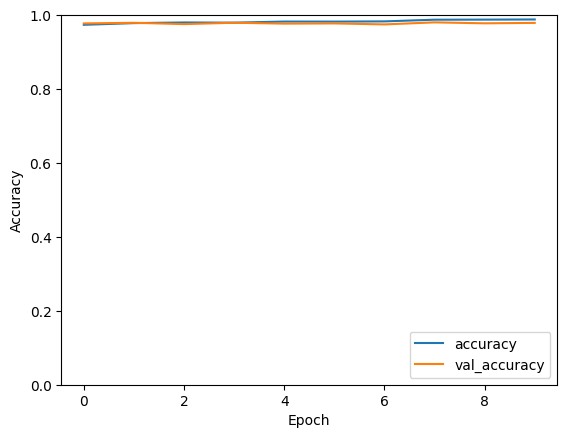

In [36]:
loss, accuracy = qat_model.evaluate(x_test, y_test_one_hot)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

import matplotlib.pyplot as plt

plt.plot(history_qat_model.history['accuracy'], label='accuracy')
plt.plot(history_qat_model.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [39]:
def rep_ds():
    for sample in tf.data.Dataset.from_tensor_slices(x_test).batch(1).take(rep_count):
        yield [tf.cast(sample, tf.float32)]

In [40]:
converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = rep_ds          # MUST yield float32
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8           # set I/O dtypes AFTER rep_ds
converter.inference_output_type = tf.int8

tflite_int8 = converter.convert()
open("./models_tflite/qat_model_2D_int8_ptq.tflite", "wb").write(tflite_int8)

INFO:tensorflow:Assets written to: /tmp/tmp_nmioru0/assets


INFO:tensorflow:Assets written to: /tmp/tmp_nmioru0/assets
/shared/b00090279/tinymlproj/lib/python3.10/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-03-04 08:25:29.246357: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-03-04 08:25:29.246398: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-03-04 08:25:29.246613: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_nmioru0
2026-03-04 08:25:29.255678: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-03-04 08:25:29.255695: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp_nmioru0
2026-03-04 08:25:29.282254: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-03-04 08

ConverterError: /shared/b00090279/tinymlproj/lib/python3.10/runpy.py:196:1: error: 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
    return _run_code(code, main_globals, None,
^
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall"]): called from
/shared/b00090279/tinymlproj/lib/python3.10/runpy.py:196:1: error: failed to legalize operation 'tf.TensorListReserve' that was explicitly marked illegal
    return _run_code(code, main_globals, None,
^
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall"]): called from
<unknown>:0: error: Lowering tensor list ops is failed. Please consider using Select TF ops and disabling `_experimental_lower_tensor_list_ops` flag in the TFLite converter object. For example, converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS, tf.lite.OpsSet.SELECT_TF_OPS]\n converter._experimental_lower_tensor_list_ops = False


In [ ]:
# Load the TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path="./models_tflite/qat_model_2D_int8_ptq.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Display Input Details
print("Input Details with Quantization Parameters:")
for input_detail in input_details:
    print(f"  Name: {input_detail['name']}")
    print(f"  Shape: {input_detail['shape']}")
    print(f"  Data Type: {input_detail['dtype']}")
    print(f"  Quantization Parameters: {input_detail['quantization']}")
    print(f"  Quantization Scale: {input_detail['quantization_parameters']['scales']}")
    print(f"  Quantization Zero Points: {input_detail['quantization_parameters']['zero_points']}\n")

# Display Output Details
print("\nOutput Details with Quantization Parameters:")
for output_detail in output_details:
    print(f"  Name: {output_detail['name']}")
    print(f"  Shape: {output_detail['shape']}")
    print(f"  Data Type: {output_detail['dtype']}")
    print(f"  Quantization Parameters: {output_detail['quantization']}")
    print(f"  Quantization Scale: {output_detail['quantization_parameters']['scales']}")
    print(f"  Quantization Zero Points: {output_detail['quantization_parameters']['zero_points']}\n")

In [59]:
import numpy as np
import tensorflow as tf

def _quantize_to_int(x_float, scale, zero_point, dtype):
    # x_q = round(x/scale + zero_point)
    x_q = np.round(x_float / scale + zero_point)

    if dtype == np.int8:
        x_q = np.clip(x_q, -128, 127).astype(np.int8)
    elif dtype == np.uint8:
        x_q = np.clip(x_q, 0, 255).astype(np.uint8)
    else:
        raise ValueError(f"Unsupported quantized dtype: {dtype}")

    return x_q

def _dequantize_from_int(x_int, scale, zero_point):
    return (x_int.astype(np.float32) - zero_point) * scale

def evaluate_int8_tflite(
    tflite_path: str,
    X: np.ndarray,
    y: np.ndarray,
    batch_size: int = 1,
    verbose: bool = True,
):
    """
    Evaluates an int8/uint8 TFLite classification model on (X, y).

    Assumptions:
    - Model output is logits or probabilities over classes (last dim = num_classes).
    - y is integer class labels (shape [N]).
    - X is float32 (recommended) with same preprocessing as training.
    """
    assert X.shape[0] == y.shape[0], "X and y must have same number of samples"
    N = X.shape[0]

    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    if len(input_details) != 1:
        raise ValueError(f"Expected 1 input tensor, got {len(input_details)}")
    if len(output_details) != 1:
        raise ValueError(f"Expected 1 output tensor, got {len(output_details)}")

    inp = input_details[0]
    out = output_details[0]

    in_index = inp["index"]
    out_index = out["index"]

    in_dtype = inp["dtype"]
    out_dtype = out["dtype"]

    in_scale, in_zero = inp["quantization"]  # (scale, zero_point)
    out_scale, out_zero = out["quantization"]

    if verbose:
        print("=== TFLite IO details ===")
        print("Input shape:", inp["shape"], "dtype:", in_dtype, "quant:", (in_scale, in_zero))
        print("Output shape:", out["shape"], "dtype:", out_dtype, "quant:", (out_scale, out_zero))

    correct = 0
    preds = np.empty((N,), dtype=np.int64)

    # Support models with fixed batch size=1 (common in fully quantized TFLite)
    model_in_shape = inp["shape"]
    fixed_batch = (model_in_shape[0] == 1)

    for i in range(N):
        x = X[i:i+1]  # [1, ...]
        # Quantize input if model expects int8/uint8
        if in_dtype in (np.int8, np.uint8):
            if in_scale == 0:
                raise ValueError("Input scale is 0; model quantization metadata seems broken.")
            x_in = _quantize_to_int(x.astype(np.float32), in_scale, in_zero, in_dtype)
        else:
            x_in = x.astype(in_dtype)

        # If model expects batch=1, keep it. If it supports dynamic batch, still OK.
        if fixed_batch and x_in.shape[0] != 1:
            x_in = x_in[:1]

        interpreter.set_tensor(in_index, x_in)
        interpreter.invoke()
        y_out = interpreter.get_tensor(out_index)

        # Dequantize output if needed
        if out_dtype in (np.int8, np.uint8):
            if out_scale == 0:
                raise ValueError("Output scale is 0; model quantization metadata seems broken.")
            y_float = _dequantize_from_int(y_out, out_scale, out_zero)
        else:
            y_float = y_out.astype(np.float32)

        pred = int(np.argmax(y_float, axis=-1)[0])
        preds[i] = pred
        if pred == int(y[i]):
            correct += 1

        if verbose and (i < 3):
            print(f"[{i}] y={int(y[i])} pred={pred} out_sample={y_float[0][:8]}")

    acc = correct / N
    if verbose:
        print(f"Accuracy: {acc:.4f} ({correct}/{N})")

    return acc, preds

In [60]:
y_test = np.argmax(y_test_one_hot, axis=1)
acc, preds = evaluate_int8_tflite("./models_tflite/qat_model_2D_int8_ptq.tflite", x_test, y_test, verbose=True)

from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds, digits=4))

=== TFLite IO details ===
Input shape: [  1 100   3] dtype: <class 'numpy.int8'> quant: (0.032081328332424164, 3)
Output shape: [1 6] dtype: <class 'numpy.int8'> quant: (0.00390625, -128)
[0] y=5 pred=5 out_sample=[0.         0.         0.         0.         0.         0.99609375]
[1] y=5 pred=5 out_sample=[0.         0.         0.         0.         0.         0.99609375]
[2] y=5 pred=5 out_sample=[0.         0.         0.         0.         0.         0.99609375]
Accuracy: 0.9660 (6845/7086)
[[ 576    3    0    0   69   38]
 [   3 2135    0    0   11    7]
 [   1    1  372    2    1    0]
 [   1    0   21  298    3    0]
 [  27    9    0    0  741   34]
 [   3    2    0    0    5 2723]]
              precision    recall  f1-score   support

           0     0.9427    0.8397    0.8882       686
           1     0.9930    0.9903    0.9916      2156
           2     0.9466    0.9867    0.9662       377
           3     0.9933    0.9226    0.9567       323
           4     0.8928    0.91